# Practice 13a - Optimization (선택 심화)

학습 결과는 **데이터 전처리·가중치 초기화·옵티마이저·활성화 함수·BatchNorm** 에 따라 크게 달라집니다. 각 요소를 한 번에 한 가지씩 격리해서 비교합니다.

| 섹션 | 내용 |
|------|------|
| 1 | 데이터 전처리 (스케일이 다르면?) |
| 2 | 가중치 초기화 (Random vs He) |
| 3 | 옵티마이저 (SGD vs Adam) |
| 4 | 활성화 함수 (Sigmoid vs ReLU) |
| 5 | BatchNorm (없음 vs 있음) |
| 6 | 최종 Test 평가 |
| 7 | 훈련 결과 시각화 (예측 샘플 + Confusion Matrix) |

> 본 노트북은 선택 심화입니다. 기본 학습을 마친 후 더 깊게 알고 싶을 때 참고하세요.

Original Authors: Seungjae Ryan Lee, Ki Hyun Kim
Source: https://github.com/deeplearningzerotoall/PyTorch


In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from torch.utils.data import TensorDataset, DataLoader

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 데이터 로드 + 60/20/20 train/val/test 분할
digits = load_digits()
X = digits.data
y = digits.target

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

# 표준화 - train 통계량을 val, test 에 동일 적용
train_mean = X_train.mean(axis=0)
train_std  = X_train.std(axis=0)
train_std[train_std == 0] = 1.0
X_train = (X_train - train_mean) / train_std
X_val   = (X_val   - train_mean) / train_std
X_test  = (X_test  - train_mean) / train_std

train_loader = DataLoader(
    TensorDataset(torch.FloatTensor(X_train), torch.LongTensor(y_train)),
    batch_size=16, shuffle=True)
val_loader = DataLoader(
    TensorDataset(torch.FloatTensor(X_val), torch.LongTensor(y_val)),
    batch_size=16, shuffle=False)
test_loader = DataLoader(
    TensorDataset(torch.FloatTensor(X_test), torch.LongTensor(y_test)),
    batch_size=16, shuffle=False)

print(f'device: {device}, Train: {len(y_train)}, Val: {len(y_val)}, Test: {len(y_test)}')


device: cuda, Train: 1077, Val: 360, Test: 360


In [2]:
# 학습 - epochs 만큼 학습 + 매 epoch val 평가
# (train_losses, train_accs, val_losses, val_accs) 반환
def train(model, train_loader, val_loader, optimizer, epochs, device):
    criterion = nn.CrossEntropyLoss()
    train_losses, train_accs, val_losses, val_accs = [], [], [], []
    for epoch in range(epochs):
        model.train()
        loss_sum, correct, count = 0.0, 0, 0
        for X_batch, Y_batch in train_loader:
            X_batch = X_batch.to(device)
            Y_batch = Y_batch.to(device)
            output = model(X_batch)
            loss = criterion(output, Y_batch)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            loss_sum += loss.item()
            correct += (output.argmax(1) == Y_batch).sum().item()
            count += len(Y_batch)
        train_loss = loss_sum / len(train_loader)
        train_acc = correct / count
        val_loss, val_acc, _ = evaluate(model, val_loader, device)   # y_pred 버림
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        val_losses.append(val_loss)
        val_accs.append(val_acc)
    return train_losses, train_accs, val_losses, val_accs


# 평가 - (loss, accuracy, y_pred) 반환
def evaluate(model, loader, device):
    model.eval()
    criterion = nn.CrossEntropyLoss()
    loss_sum, correct, count = 0.0, 0, 0
    preds = []
    with torch.no_grad():
        for X_batch, Y_batch in loader:
            X_batch = X_batch.to(device)
            Y_batch = Y_batch.to(device)
            output = model(X_batch)
            loss_sum += criterion(output, Y_batch).item()
            correct += (output.argmax(1) == Y_batch).sum().item()
            count += len(Y_batch)
            preds.append(output.argmax(1).cpu())
    y_pred = torch.cat(preds).numpy()
    return loss_sum / len(loader), correct / count, y_pred


---
# 1. 데이터 전처리 (Data Preprocessing)

특징의 스케일이 다르면 경사하강법이 지그재그로 수렴합니다.
표준화: $x_i^{\text{new}} = (x_i - \mu_i) / \sigma_i$

효과를 보기 위해 **앞 32개 특징의 스케일을 20배로 키운** 데이터로 실험합니다. 같은 데이터를 (a) 표준화 없이, (b) 표준화 적용해서 비교합니다.

In [3]:
# 스케일 불균형 데이터 생성: 앞 32개 특징을 20배로
X_skewed = X.copy()
X_skewed[:, :32] *= 20

# 같은 seed로 분할 -> y는 위에서 만든 y_train/y_val/y_test와 동일
X_skewed_temp, X_skewed_test, _, _ = train_test_split(
    X_skewed, y, test_size=0.2, random_state=42, stratify=y)
X_skewed_train, X_skewed_val, _, _ = train_test_split(
    X_skewed_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

# (a) Raw skewed - 표준화 없음
# (b) Scaled - 표준화 적용
skewed_train_mean = X_skewed_train.mean(axis=0)
skewed_train_std  = X_skewed_train.std(axis=0)
skewed_train_std[skewed_train_std == 0] = 1.0
X_skewed_train_scaled = (X_skewed_train - skewed_train_mean) / skewed_train_std
X_skewed_val_scaled   = (X_skewed_val   - skewed_train_mean) / skewed_train_std

skewed_raw_train_loader = DataLoader(
    TensorDataset(torch.FloatTensor(X_skewed_train), torch.LongTensor(y_train)),
    batch_size=16, shuffle=True)
skewed_raw_val_loader = DataLoader(
    TensorDataset(torch.FloatTensor(X_skewed_val), torch.LongTensor(y_val)),
    batch_size=16, shuffle=False)
skewed_scaled_train_loader = DataLoader(
    TensorDataset(torch.FloatTensor(X_skewed_train_scaled), torch.LongTensor(y_train)),
    batch_size=16, shuffle=True)
skewed_scaled_val_loader = DataLoader(
    TensorDataset(torch.FloatTensor(X_skewed_val_scaled), torch.LongTensor(y_val)),
    batch_size=16, shuffle=False)

print(f'Raw   skewed - mean: {X_skewed_train.mean():.0f}, std: {X_skewed_train.std():.0f}')
print(f'Scaled skewed - mean: {X_skewed_train_scaled.mean():.0f}, std: {X_skewed_train_scaled.std():.0f}')


Raw   skewed - mean: 52, std: 98
Scaled skewed - mean: 0, std: 1


Raw    (skewed)  -> Val Acc: 0.297
Scaled (skewed)  -> Val Acc: 0.947


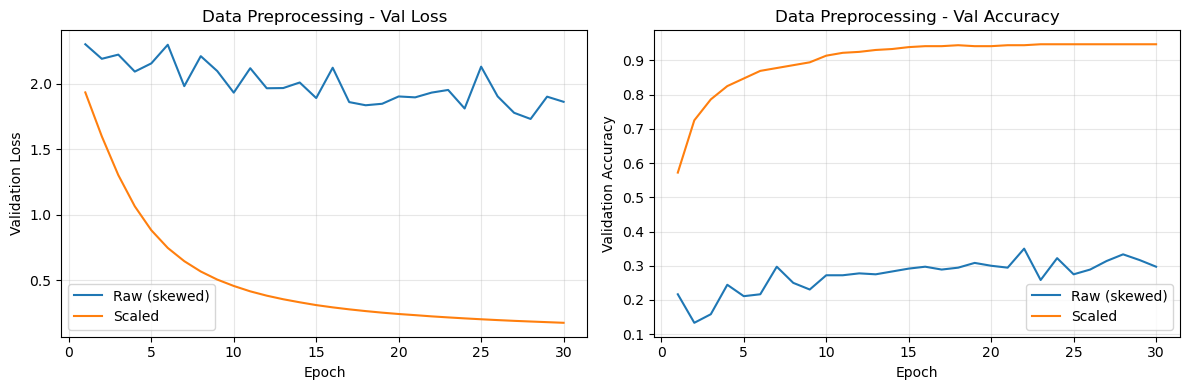

스케일이 다르면 SGD가 수렴하지 못합니다. 표준화는 필수 전처리입니다.


In [4]:
# === Raw (표준화 없음) ===
torch.manual_seed(42)
model_raw = nn.Sequential(nn.Linear(64, 128), nn.ReLU(), nn.Linear(128, 10)).to(device)
optimizer_raw = torch.optim.SGD(model_raw.parameters(), lr=0.01)
train_losses_raw, train_accs_raw, val_losses_raw, val_accs_raw = train(
    model_raw, skewed_raw_train_loader, skewed_raw_val_loader, optimizer_raw, epochs=30, device=device)

# === Scaled (표준화) ===
torch.manual_seed(42)
model_scaled = nn.Sequential(nn.Linear(64, 128), nn.ReLU(), nn.Linear(128, 10)).to(device)
optimizer_scaled = torch.optim.SGD(model_scaled.parameters(), lr=0.01)
train_losses_scaled, train_accs_scaled, val_losses_scaled, val_accs_scaled = train(
    model_scaled, skewed_scaled_train_loader, skewed_scaled_val_loader, optimizer_scaled, epochs=30, device=device)

print(f'Raw    (skewed)  -> Val Acc: {val_accs_raw[-1]:.3f}')
print(f'Scaled (skewed)  -> Val Acc: {val_accs_scaled[-1]:.3f}')

# 비교 그래프 - Validation 만
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs_range = range(1, len(val_losses_raw) + 1)
axes[0].plot(epochs_range, val_losses_raw, label='Raw (skewed)')
axes[0].plot(epochs_range, val_losses_scaled, label='Scaled')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Validation Loss')
axes[0].set_title('Data Preprocessing - Val Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(epochs_range, val_accs_raw, label='Raw (skewed)')
axes[1].plot(epochs_range, val_accs_scaled, label='Scaled')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Validation Accuracy')
axes[1].set_title('Data Preprocessing - Val Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()
print('스케일이 다르면 SGD가 수렴하지 못합니다. 표준화는 필수 전처리입니다.')


---
# 2. 가중치 초기화 (Weight Initialization)

| 방법 | 설명 | 적합한 활성 함수 |
|------|------|------|
| Random | $N(0, 0.2^2)$ — 너무 큰 분산 | - |
| He (Kaiming) | $N(0, 2/n_{in})$ | ReLU |

**8층 깊은 네트워크 + SGD**에서 초기화의 차이를 확인합니다.

Random init -> Val Acc: 0.911
He init     -> Val Acc: 0.939


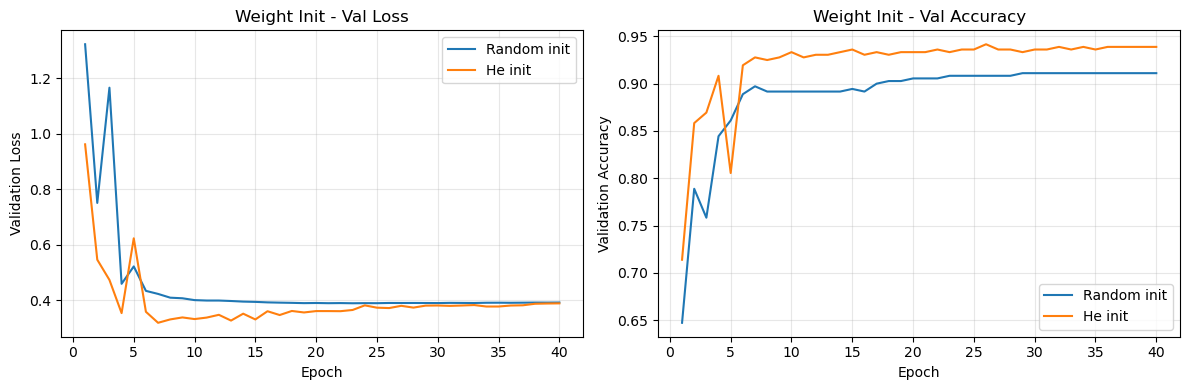

큰 Random 초기화는 학습이 되지 않습니다. He 초기화를 사용하세요.


In [5]:
# === 큰 Random 초기화 (8층) ===
torch.manual_seed(42)
model_random = nn.Sequential(
    nn.Linear(64, 128), nn.ReLU(),
    nn.Linear(128, 128), nn.ReLU(),
    nn.Linear(128, 128), nn.ReLU(),
    nn.Linear(128, 128), nn.ReLU(),
    nn.Linear(128, 128), nn.ReLU(),
    nn.Linear(128, 128), nn.ReLU(),
    nn.Linear(128, 128), nn.ReLU(),
    nn.Linear(128, 10)
)
for layer in model_random:
    if isinstance(layer, nn.Linear):
        nn.init.normal_(layer.weight, mean=0.0, std=0.2)
        nn.init.normal_(layer.bias, mean=0.0, std=0.2)
model_random = model_random.to(device)
optimizer_random = torch.optim.SGD(model_random.parameters(), lr=0.01)
train_losses_random, train_accs_random, val_losses_random, val_accs_random = train(model_random, train_loader, val_loader, optimizer_random, epochs=40, device=device)

# === He (Kaiming) 초기화 (8층) ===
torch.manual_seed(42)
model_he = nn.Sequential(
    nn.Linear(64, 128), nn.ReLU(),
    nn.Linear(128, 128), nn.ReLU(),
    nn.Linear(128, 128), nn.ReLU(),
    nn.Linear(128, 128), nn.ReLU(),
    nn.Linear(128, 128), nn.ReLU(),
    nn.Linear(128, 128), nn.ReLU(),
    nn.Linear(128, 128), nn.ReLU(),
    nn.Linear(128, 10)
)
for layer in model_he:
    if isinstance(layer, nn.Linear):
        nn.init.kaiming_normal_(layer.weight, nonlinearity='relu')
model_he = model_he.to(device)
optimizer_he = torch.optim.SGD(model_he.parameters(), lr=0.01)
train_losses_he, train_accs_he, val_losses_he, val_accs_he = train(model_he, train_loader, val_loader, optimizer_he, epochs=40, device=device)

print(f'Random init -> Val Acc: {val_accs_random[-1]:.3f}')
print(f'He init     -> Val Acc: {val_accs_he[-1]:.3f}')

# 비교 그래프 - Validation 만
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs_range = range(1, len(val_losses_random) + 1)
axes[0].plot(epochs_range, val_losses_random, label='Random init')
axes[0].plot(epochs_range, val_losses_he,  label='He init')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Validation Loss')
axes[0].set_title('Weight Init - Val Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(epochs_range, val_accs_random, label='Random init')
axes[1].plot(epochs_range, val_accs_he,  label='He init')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Validation Accuracy')
axes[1].set_title('Weight Init - Val Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()
print('큰 Random 초기화는 학습이 되지 않습니다. He 초기화를 사용하세요.')


---
# 3. 옵티마이저 비교 (Optimizer Comparison)

| 옵티마이저 | 설명 |
|---|---|
| SGD | $\theta \leftarrow \theta - \rho\, \partial J / \partial \theta$ |
| Adam | 1차 + 2차 모멘트로 적응적 학습률 |

SGD  (lr=0.01)  -> Val Acc: 0.964
Adam (lr=0.001) -> Val Acc: 0.983


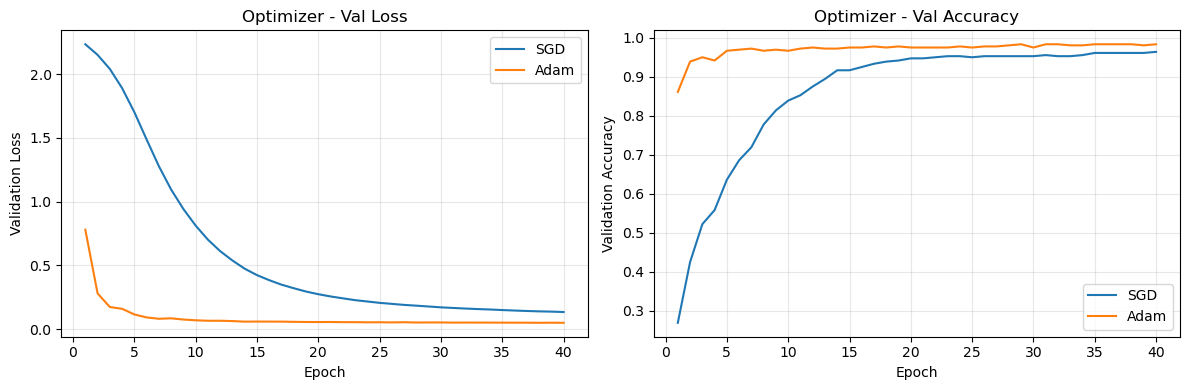

Adam은 적응적 학습률로 SGD보다 빠르게 수렴합니다.


In [6]:
# === SGD ===
torch.manual_seed(42)
model_sgd = nn.Sequential(
    nn.Linear(64, 128), nn.ReLU(),
    nn.Linear(128, 64), nn.ReLU(),
    nn.Linear(64, 10)
).to(device)
optimizer_sgd = torch.optim.SGD(model_sgd.parameters(), lr=0.01)
train_losses_sgd, train_accs_sgd, val_losses_sgd, val_accs_sgd = train(model_sgd, train_loader, val_loader, optimizer_sgd, epochs=40, device=device)

# === Adam ===
torch.manual_seed(42)
model_adam = nn.Sequential(
    nn.Linear(64, 128), nn.ReLU(),
    nn.Linear(128, 64), nn.ReLU(),
    nn.Linear(64, 10)
).to(device)
optimizer_adam = torch.optim.Adam(model_adam.parameters(), lr=0.001)
train_losses_adam, train_accs_adam, val_losses_adam, val_accs_adam = train(model_adam, train_loader, val_loader, optimizer_adam, epochs=40, device=device)

print(f'SGD  (lr=0.01)  -> Val Acc: {val_accs_sgd[-1]:.3f}')
print(f'Adam (lr=0.001) -> Val Acc: {val_accs_adam[-1]:.3f}')

# 비교 그래프 - Validation 만
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs_range = range(1, len(val_losses_sgd) + 1)
axes[0].plot(epochs_range, val_losses_sgd,  label='SGD')
axes[0].plot(epochs_range, val_losses_adam, label='Adam')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Validation Loss')
axes[0].set_title('Optimizer - Val Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(epochs_range, val_accs_sgd,  label='SGD')
axes[1].plot(epochs_range, val_accs_adam, label='Adam')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Validation Accuracy')
axes[1].set_title('Optimizer - Val Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()
print('Adam은 적응적 학습률로 SGD보다 빠르게 수렴합니다.')


---
# 4. 활성 함수 (Activation Functions)

Sigmoid/Tanh는 $|z|$가 커지면 gradient → 0 (**포화**).
ReLU: $\max(0, z)$ — 포화 없이 빠른 학습.

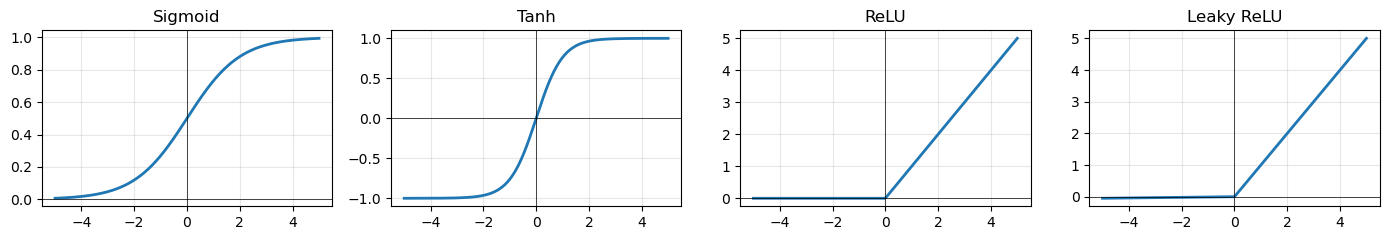

In [7]:
# 활성 함수 그래프
z = np.linspace(-5, 5, 200)
fig, axes = plt.subplots(1, 4, figsize=(14, 2.5))

axes[0].plot(z, 1 / (1 + np.exp(-z)), linewidth=2)
axes[0].set_title('Sigmoid')

axes[1].plot(z, np.tanh(z), linewidth=2)
axes[1].set_title('Tanh')

axes[2].plot(z, np.maximum(0, z), linewidth=2)
axes[2].set_title('ReLU')

axes[3].plot(z, np.where(z > 0, z, 0.01 * z), linewidth=2)
axes[3].set_title('Leaky ReLU')

for ax in axes:
    ax.grid(alpha=0.3)
    ax.axhline(0, color='k', lw=0.5)
    ax.axvline(0, color='k', lw=0.5)
plt.tight_layout(); plt.show()


Sigmoid -> Val Acc: 0.794
ReLU    -> Val Acc: 0.953


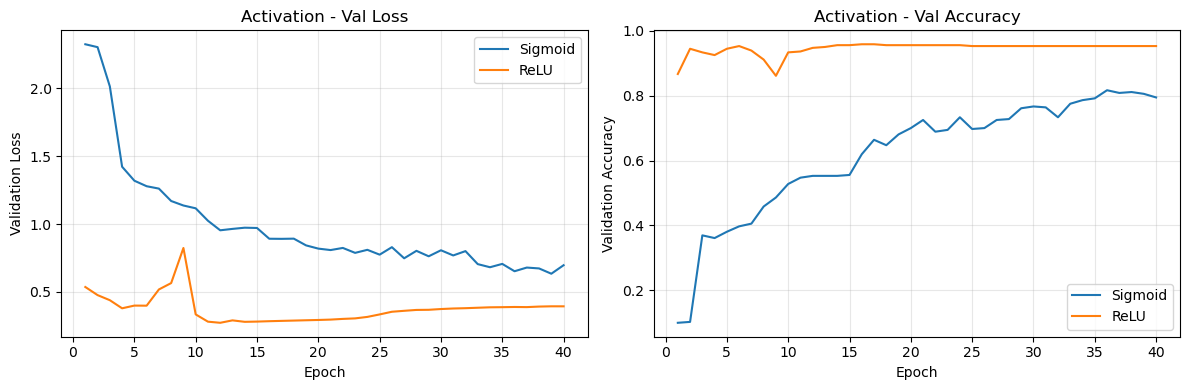

깊은 네트워크에서 Sigmoid는 gradient vanishing으로 학습이 어렵습니다.


In [8]:
# === Sigmoid (8층) ===
torch.manual_seed(42)
model_sigmoid = nn.Sequential(
    nn.Linear(64, 128), nn.Sigmoid(),
    nn.Linear(128, 128), nn.Sigmoid(),
    nn.Linear(128, 128), nn.Sigmoid(),
    nn.Linear(128, 128), nn.Sigmoid(),
    nn.Linear(128, 128), nn.Sigmoid(),
    nn.Linear(128, 128), nn.Sigmoid(),
    nn.Linear(128, 128), nn.Sigmoid(),
    nn.Linear(128, 10)
)
for layer in model_sigmoid:
    if isinstance(layer, nn.Linear):
        nn.init.xavier_uniform_(layer.weight)
model_sigmoid = model_sigmoid.to(device)
optimizer_sigmoid = torch.optim.Adam(model_sigmoid.parameters(), lr=0.001)
train_losses_sigmoid, train_accs_sigmoid, val_losses_sigmoid, val_accs_sigmoid = train(model_sigmoid, train_loader, val_loader, optimizer_sigmoid, epochs=40, device=device)

# === ReLU (8층) ===
torch.manual_seed(42)
model_relu = nn.Sequential(
    nn.Linear(64, 128), nn.ReLU(),
    nn.Linear(128, 128), nn.ReLU(),
    nn.Linear(128, 128), nn.ReLU(),
    nn.Linear(128, 128), nn.ReLU(),
    nn.Linear(128, 128), nn.ReLU(),
    nn.Linear(128, 128), nn.ReLU(),
    nn.Linear(128, 128), nn.ReLU(),
    nn.Linear(128, 10)
)
for layer in model_relu:
    if isinstance(layer, nn.Linear):
        nn.init.kaiming_normal_(layer.weight, nonlinearity='relu')
model_relu = model_relu.to(device)
optimizer_relu = torch.optim.Adam(model_relu.parameters(), lr=0.001)
train_losses_relu, train_accs_relu, val_losses_relu, val_accs_relu = train(model_relu, train_loader, val_loader, optimizer_relu, epochs=40, device=device)

print(f'Sigmoid -> Val Acc: {val_accs_sigmoid[-1]:.3f}')
print(f'ReLU    -> Val Acc: {val_accs_relu[-1]:.3f}')

# 비교 그래프 - Validation 만
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs_range = range(1, len(val_losses_sigmoid) + 1)
axes[0].plot(epochs_range, val_losses_sigmoid,  label='Sigmoid')
axes[0].plot(epochs_range, val_losses_relu, label='ReLU')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Validation Loss')
axes[0].set_title('Activation - Val Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(epochs_range, val_accs_sigmoid,  label='Sigmoid')
axes[1].plot(epochs_range, val_accs_relu, label='ReLU')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Validation Accuracy')
axes[1].set_title('Activation - Val Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()
print('깊은 네트워크에서 Sigmoid는 gradient vanishing으로 학습이 어렵습니다.')


---
# 5. 배치 정규화 (Batch Normalization)

각 층 출력을 미니배치 단위로 정규화 → 학습 안정화, 더 큰 학습률 사용 가능.

$$\hat{z}_i = \frac{z_i - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}}, \quad z'_i = \gamma \hat{z}_i + \beta$$

**높은 학습률(SGD lr=0.1)**에서 BatchNorm의 안정화 효과를 확인합니다.

Without BN -> Val Acc: 0.969
With BN    -> Val Acc: 0.981


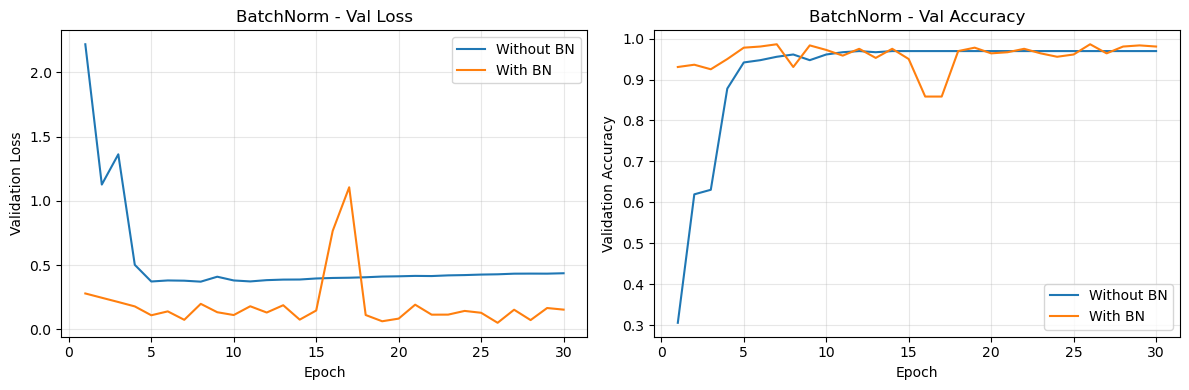

BatchNorm을 사용하면 높은 learning rate에서도 안정적으로 수렴합니다.


In [9]:
# === Without BatchNorm ===
torch.manual_seed(42)
model_no_bn = nn.Sequential(
    nn.Linear(64, 128), nn.ReLU(),
    nn.Linear(128, 128), nn.ReLU(),
    nn.Linear(128, 128), nn.ReLU(),
    nn.Linear(128, 128), nn.ReLU(),
    nn.Linear(128, 10)
).to(device)
optimizer_no_bn = torch.optim.SGD(model_no_bn.parameters(), lr=0.1)
train_losses_no_bn, train_accs_no_bn, val_losses_no_bn, val_accs_no_bn = train(model_no_bn, train_loader, val_loader, optimizer_no_bn, epochs=30, device=device)

# === With BatchNorm ===
torch.manual_seed(42)
model_bn = nn.Sequential(
    nn.Linear(64, 128), nn.BatchNorm1d(128), nn.ReLU(),
    nn.Linear(128, 128), nn.BatchNorm1d(128), nn.ReLU(),
    nn.Linear(128, 128), nn.BatchNorm1d(128), nn.ReLU(),
    nn.Linear(128, 128), nn.BatchNorm1d(128), nn.ReLU(),
    nn.Linear(128, 10)
).to(device)
optimizer_bn = torch.optim.SGD(model_bn.parameters(), lr=0.1)
train_losses_bn, train_accs_bn, val_losses_bn, val_accs_bn = train(model_bn, train_loader, val_loader, optimizer_bn, epochs=30, device=device)

print(f'Without BN -> Val Acc: {val_accs_no_bn[-1]:.3f}')
print(f'With BN    -> Val Acc: {val_accs_bn[-1]:.3f}')

# 비교 그래프 - Validation 만
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs_range = range(1, len(val_losses_no_bn) + 1)
axes[0].plot(epochs_range, val_losses_no_bn, label='Without BN')
axes[0].plot(epochs_range, val_losses_bn,   label='With BN')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Validation Loss')
axes[0].set_title('BatchNorm - Val Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(epochs_range, val_accs_no_bn, label='Without BN')
axes[1].plot(epochs_range, val_accs_bn,   label='With BN')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Validation Accuracy')
axes[1].set_title('BatchNorm - Val Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()
print('BatchNorm을 사용하면 높은 learning rate에서도 안정적으로 수렴합니다.')


---
# 6. 최종 Test 평가

각 비교에서 살아남은 (또는 마지막으로 학습된) 모델들을 학습 중 한 번도 보지 않은 **test set** 에서 평가합니다.

In [10]:
# 각 섹션의 대표 모델을 test set에서 평가
# §1 표준화는 X_test (원본 스케일) 가 아닌 표준화된 X_skewed_test_scaled 가 필요하므로 별도 loader 생성
X_skewed_test_scaled = (X_skewed_test - skewed_train_mean) / skewed_train_std
skewed_scaled_test_loader = DataLoader(
    TensorDataset(torch.FloatTensor(X_skewed_test_scaled), torch.LongTensor(y_test)),
    batch_size=16, shuffle=False)

scaled_loss, scaled_acc, _      = evaluate(model_scaled, skewed_scaled_test_loader, device)
he_loss,     he_acc,     _      = evaluate(model_he,     test_loader, device)
adam_loss,   adam_acc,   _      = evaluate(model_adam,   test_loader, device)
relu_loss,   relu_acc,   _      = evaluate(model_relu,   test_loader, device)
bn_loss,     bn_acc,     y_pred = evaluate(model_bn,     test_loader, device)  # § 7 에서 y_pred 사용

print(f'§1 Scaled (preprocess)  test_loss={scaled_loss:.4f}  test_acc={scaled_acc:.4f}')
print(f'§2 He init              test_loss={he_loss:.4f}  test_acc={he_acc:.4f}')
print(f'§3 Adam                 test_loss={adam_loss:.4f}  test_acc={adam_acc:.4f}')
print(f'§4 ReLU (8-layer)       test_loss={relu_loss:.4f}  test_acc={relu_acc:.4f}')
print(f'§5 BatchNorm            test_loss={bn_loss:.4f}  test_acc={bn_acc:.4f}')


§1 Scaled (preprocess)  test_loss=0.1851  test_acc=0.9500
§2 He init              test_loss=0.2061  test_acc=0.9639
§3 Adam                 test_loss=0.0725  test_acc=0.9806
§4 ReLU (8-layer)       test_loss=0.1895  test_acc=0.9778
§5 BatchNorm            test_loss=0.0827  test_acc=0.9889


---
# 7. 훈련 결과 시각화 (BatchNorm 모델)

직전 셀에서 받은 `y_pred` (BatchNorm 모델 기준) 로 (재예측 없이) 두 가지를 함께 봅니다.

- **틀린 예측 4 개**: 1 × 4 그리드, 제목 `True:X / Pred:Y` (빨강)
- **Confusion Matrix**: 어떤 숫자가 어떤 숫자로 오인되는지

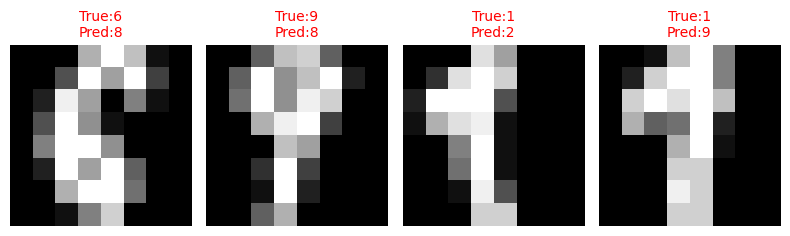

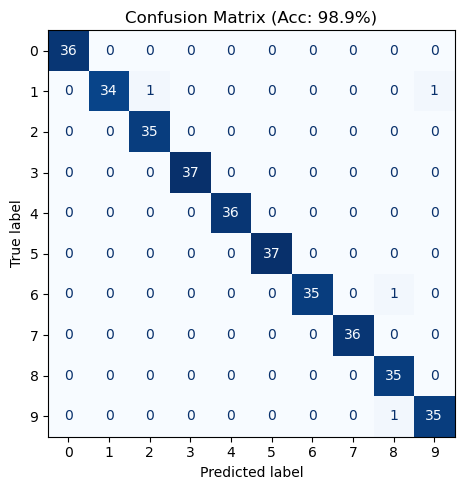

In [11]:

# (1) 틀린 예측 4 개 - 1 x 4 subplot
wrong_idx = np.where(y_pred != y_test)[0]
X_test_display = X_test * train_std + train_mean   # 표준화 역변환 - 원본 픽셀 (0~16) 로 복원
fig, axes = plt.subplots(1, 4, figsize=(8, 2.5))
for i in range(min(4, len(wrong_idx))):
    idx = wrong_idx[i]
    axes[i].imshow(X_test_display[idx].reshape(8, 8), cmap='gray')
    axes[i].set_title(f'True:{y_test[idx]}\nPred:{y_pred[idx]}', color='red', fontsize=10)
    axes[i].axis('off')
plt.tight_layout(); plt.show()

# (2) Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(10))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Confusion Matrix (Acc: {bn_acc:.1%})')
plt.tight_layout(); plt.show()


---
### 연습 문제

1. 옵티마이저 비교에 `SGD + Momentum 0.9`를 추가해 보세요.
2. 가중치 초기화 비교에서 `nn.init.xavier_uniform_`을 사용해 보세요.
3. (도전) 배치 정규화 실험을 lr=0.001, 0.01, 0.1에서 반복하고, BN이 큰 학습률에서 얼마나 유리한지 보여주세요.

In [12]:
# 연습 문제 풀이 공간

